In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from order_fingers import TouchTracker
import sqlite3
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
db_path = "./labeled_new.sqlite"

In [4]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        rtParent.title AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title = 'No Gesture' THEN 0 ELSE 1 END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
),

no_gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        'No Gesture' AS gesture,
        'No Gesture' AS parent_gesture,
        s.participant_id,
        0 AS is_gesture,
        NULL  AS group_id
    FROM sensorData sd
    LEFT JOIN gesture_samples gs 
      ON gs.id = sd.id -- Check if this row was already labeled as a gesture
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    
    -- Exclude rows that were found in gesture_samples (gs.id IS NULL)
    -- Also keep your original session_task_id and 'Szenarien' filters
    WHERE gs.id IS NULL
      AND sd.session_task_id IN (
          SELECT DISTINCT session_task_id FROM preciseMarker
      )
      AND rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
UNION ALL
SELECT * FROM no_gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(db_path) as conn:
    # Use pandas to execute the query and load results into a DataFrame
    df = pd.read_sql_query(query, conn)

df.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,group_id
0,1668ffd2-1939-41a9-97dc-906cc8041084,002f4422-1f7b-4859-8f03-467e1f752000,325,2025-10-07 14:11:50,0,176.685837,0.410596,2048.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,2025-10-07 14:11:50
1,7cc63c58-ff05-4c43-ace6-ce2038a4da66,002f4422-1f7b-4859-8f03-467e1f752000,326,2025-10-07 14:11:50,0,176.686600,0.409281,2062.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,2025-10-07 14:11:50
2,4e727221-45fa-432a-b972-5ee640c533a7,002f4422-1f7b-4859-8f03-467e1f752000,327,2025-10-07 14:11:50,0,176.686218,0.407342,2065.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,2025-10-07 14:11:50
3,cd025956-225d-45c0-9380-76c934284585,002f4422-1f7b-4859-8f03-467e1f752000,328,2025-10-07 14:11:50,0,176.686218,0.406749,2072.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,2025-10-07 14:11:50
4,2337a772-c876-4cd2-a5e7-ac42f6dad3ab,002f4422-1f7b-4859-8f03-467e1f752000,329,2025-10-07 14:11:50,0,176.686600,0.405720,2073.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,2025-10-07 14:11:50


In [5]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    'Szenarien' AS gesture,
    'Szenarien' AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' THEN 0 ELSE 1 END AS is_gesture,
    -- Get marker type without the 'marker:' prefix and ':start' suffix
    SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) AS marker_label,
    smt.group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(db_path) as conn:
    szenarien_df = pd.read_sql_query(szenarien_query, conn)
szenarien_df.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,marker_label,group_id
0,1668ffd2-1939-41a9-97dc-906cc8041084,002f4422-1f7b-4859-8f03-467e1f752000,325,2025-10-07 14:11:50,0,176.685837,0.410596,2048.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,2025-10-07 14:11:50
1,7cc63c58-ff05-4c43-ace6-ce2038a4da66,002f4422-1f7b-4859-8f03-467e1f752000,326,2025-10-07 14:11:50,0,176.686600,0.409281,2062.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,2025-10-07 14:11:50
2,4e727221-45fa-432a-b972-5ee640c533a7,002f4422-1f7b-4859-8f03-467e1f752000,327,2025-10-07 14:11:50,0,176.686218,0.407342,2065.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,2025-10-07 14:11:50
3,cd025956-225d-45c0-9380-76c934284585,002f4422-1f7b-4859-8f03-467e1f752000,328,2025-10-07 14:11:50,0,176.686218,0.406749,2072.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,2025-10-07 14:11:50
4,2337a772-c876-4cd2-a5e7-ac42f6dad3ab,002f4422-1f7b-4859-8f03-467e1f752000,329,2025-10-07 14:11:50,0,176.686600,0.405720,2073.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,2025-10-07 14:11:50


In [6]:
# Print unique marker_types in szenarien_df with their respective counts
print(szenarien_df['marker_label'].value_counts())

marker_label
No Gesture                        3235
Tap and Hold                      1908
Spread Swipe                      1416
Single Swipe                      1016
Pinch Swipe                        838
Two-Finger Opposite Double Tap     514
Two-Finger Tap                     331
Two-Finger Double Tap              296
Double Tap                         242
Two-Finger Opposite Tap            228
Single Tap                          16
Name: count, dtype: int64


In [7]:
print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Data loaded: 348671 rows, 26 columns


In [8]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['time_diff'] = df.groupby(['session_task_id', 'timestamp']).cumcount()
df['recordings_per_second'] = df.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df['estimated_timestamp'] = df['timestamp'] + pd.to_timedelta(df['time_diff'] / df['recordings_per_second'], unit='s')
df = df.drop(columns=['time_diff', 'recordings_per_second'])

df["timestamp_ms"] = (df["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348671 entries, 0 to 348670
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   id                      348671 non-null  object        
 1   session_task_id         348671 non-null  object        
 2   session_task_row_index  348671 non-null  int64         
 3   timestamp               348671 non-null  datetime64[ns]
 4   button_pressed          348671 non-null  int64         
 5   motor_angle             348671 non-null  float64       
 6   touch_1_position        232133 non-null  float64       
 7   touch_1_pressure        232133 non-null  float64       
 8   touch_1_channel         232133 non-null  float64       
 9   touch_2_position        191116 non-null  float64       
 10  touch_2_pressure        191116 non-null  float64       
 11  touch_2_channel         191116 non-null  float64       
 12  touch_3_position        98227 

In [10]:
import pandas as pd
import numpy as np

# Define the columns used for each touch
TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame, tracker):
    """
    Processes a DataFrame sequentially to assign stable touch IDs and then 
    reorders the touch data columns based on those stable IDs.

    Args:
        df: The input DataFrame containing touch_N_position/pressure/channel.
        tracker: The initialized TouchTracker object (e.g., TouchTracker()).

    Returns:
        A new DataFrame with the touch columns stabilized by ID.
    """
    
    # List to store the 'matched' output from tracker.assign_ids() for each row
    all_matched_touches = []
    
    # --- 1. Sequential Processing (Extract & Assign IDs) ---
    print("Step 1/2: Running TouchTracker sequentially...")
    
    # Iterate over the rows of the DataFrame
    for index, row in df.iterrows():
        new_touches = []
        
        # Extract the touches for the current row into the required list format
        for prefix in TOUCH_PREFIXES:
            pos_col = f'{prefix}_position'
            press_col = f'{prefix}_pressure'
            chan_col = f'{prefix}_channel'
            
            # Check if the position data exists (assuming NaNs mark an inactive touch)
            if pd.notna(row[pos_col]):
                pos = row[pos_col]
                press = row[press_col]
                chan = row[chan_col]
                # The input to assign_ids is: (rel_pos, pressure, channel)
                new_touches.append((pos, press, chan))
            
        # Run the tracker's assignment function to get stable IDs
        # The result is: [(id, pos, press, chan), ...]
        matched_touches = tracker.assign_ids(new_touches)
        all_matched_touches.append(matched_touches)

    # --- 2. Stabilization (Sort by ID and Slot) ---
    print("Step 2/2: Stabilizing touch columns by ID...")
    
    # Prepare the new column names for the output DataFrame
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    
    # Prepare the list of rows for the new DataFrame
    stabilized_rows = []
    
    for matched_list in all_matched_touches:
        # Sort the matched list by the stable ID (the first element of the tuple)
        # This ensures that ID_10 always gets slotted before ID_20.
        matched_list.sort(key=lambda x: x[0]) 
        
        row_data = []
        
        for i in range(MAX_TOUCHES):
            if i < len(matched_list):
                # Touch is present: (id, pos, press, chan)
                # We want the data from indices 1, 2, 3 (pos, press, chan)
                touch_data = matched_list[i][1:]
                row_data.extend(touch_data)
            else:
                # Touch is absent: Fill with NaN
                row_data.extend([np.nan] * len(TOUCH_COLUMNS_BASE))
                
        stabilized_rows.append(row_data)

    # Create the new DataFrame with stabilized data
    stabilized_df = pd.DataFrame(stabilized_rows, index=df.index, columns=new_col_names)
    
    # Optional: Add a column for the active IDs for verification
    # stabilized_df['active_ids'] = [[m[0] for m in row] for row in all_matched_touches]
    
    return stabilized_df

# --- Example of how to use it ---
# Assuming 'df' is your existing DataFrame and 'TouchTracker' is defined:
tracker = TouchTracker()
stabilized_touch_data = process_and_stabilize_touches(df.copy(), tracker)

# # Final step: Replace the old columns in your original DataFrame
# # 1. Get non-touch columns from the original df
non_touch_cols = [c for c in df.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df[non_touch_cols].copy()

# # 2. Join the non-touch columns with the new stabilized touch data
final_df = final_df.join(stabilized_touch_data)
print("Stabilization Complete.")

Step 1/2: Running TouchTracker sequentially...
Step 2/2: Stabilizing touch columns by ID...
Stabilization Complete.


In [11]:
old_df = df.copy()
df = final_df.copy()

In [12]:
df.describe()

,session_task_row_index,timestamp,button_pressed,motor_angle,is_gesture,estimated_timestamp,timestamp_ms,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel
count,348671.000000,348671,348671.000000,348671.000000,348671.000000,348671,3.486710e+05,232133.000000,232133.000000,232133.000000,191116.000000,191116.000000,191116.000000,98227.000000,98227.000000,98227.000000,44512.000000,44512.000000,44512.000000,2719.000000,2719.000000,2719.000000
mean,1351.957352,2025-10-28 12:44:53.715740416,0.004683,96.586587,0.192276,2025-10-28 12:44:54.208869888,1.761655e+12,2.450260,1188.177915,3.725563,3.386587,1203.799980,3.793879,3.111850,1191.849797,3.715038,3.319349,1115.448913,3.677098,3.296140,693.423685,3.005885
min,0.000000,2025-10-03 15:34:58,0.000000,-3.979530,0.000000,2025-10-03 15:34:58,1.759506e+12,0.000082,41.000000,1.000000,0.000102,41.000000,1.000000,0.000000,41.000000,1.000000,0.000045,41.000000,1.000000,0.002335,41.000000,1.000000
25%,549.000000,2025-10-03 16:28:51,0.000000,19.129890,0.000000,2025-10-03 16:28:51.958333440,1.759509e+12,0.829685,792.000000,3.000000,2.632040,774.000000,3.000000,1.699851,761.000000,3.000000,1.882944,799.000000,3.000000,1.722073,424.000000,3.000000
50%,1095.000000,2025-10-07 13:32:52,0.000000,113.333572,0.000000,2025-10-07 13:32:52.964912384,1.759844e+12,2.267183,1110.000000,4.000000,3.412040,1140.000000,4.000000,3.286338,1075.000000,4.000000,3.249647,1040.000000,4.000000,3.730474,631.000000,3.000000
75%,1797.000000,2025-12-28 18:25:46,0.000000,151.870239,0.000000,2025-12-28 18:25:46.703947264,1.766946e+12,3.694535,1493.000000,4.000000,4.485702,1563.000000,4.000000,4.406790,1537.000000,4.000000,5.267069,1409.000000,4.000000,4.851649,919.000000,4.000000
max,7535.000000,2025-12-29 10:21:47,1.000000,249.557968,1.000000,2025-12-29 10:21:47.976744186,1.767004e+12,6.282874,4813.000000,11.000000,6.282701,4864.000000,11.000000,6.282947,3013.000000,9.000000,6.283051,2706.000000,7.000000,6.281097,2330.000000,6.000000
std,1135.516792,NaN,0.068276,71.586194,0.394089,NaN,3.256090e+09,1.729424,627.669393,1.099528,1.678490,610.270602,0.977628,1.807614,609.526299,0.885515,1.961357,516.733542,0.876273,1.833774,416.400480,0.937311


In [13]:
# Check the distribution of each gesture class
print("\nCLASS DISTRIBUTION:")
class_counts = df['parent_gesture'].value_counts()
for gesture, count in class_counts.items():
    print(f"  {gesture}: {count} samples")
total_samples = len(df)
print(f"Total samples: {total_samples}")
print("\nCLASS DISTRIBUTION (PERCENTAGES):")
for gesture, count in class_counts.items():
    percentage = (count / total_samples) * 100
    print(f"  {gesture}: {percentage:.2f}%")
    


CLASS DISTRIBUTION:
  No Gesture: 281630 samples
  Szenarien: 26359 samples
  Tap and Hold: 9653 samples
  Pinch Swipe: 9106 samples
  Spread Swipe: 6986 samples
  Single Swipe: 4933 samples
  Two-Finger Opposite Double Tap: 2255 samples
  Two-Finger Double Tap: 2123 samples
  Double Tap: 2045 samples
  Two-Finger Opposite Tap: 1322 samples
  Two-Finger Tap: 1210 samples
  Single Tap: 1049 samples
Total samples: 348671

CLASS DISTRIBUTION (PERCENTAGES):
  No Gesture: 80.77%
  Szenarien: 7.56%
  Tap and Hold: 2.77%
  Pinch Swipe: 2.61%
  Spread Swipe: 2.00%
  Single Swipe: 1.41%
  Two-Finger Opposite Double Tap: 0.65%
  Two-Finger Double Tap: 0.61%
  Double Tap: 0.59%
  Two-Finger Opposite Tap: 0.38%
  Two-Finger Tap: 0.35%
  Single Tap: 0.30%


In [15]:
SAMPLING_RATE_HZ = 70
WINDOW_SIZE_MS = 300
WINDOW_OVERLAP_PERCENT = 70

WINDOW_SIZE_SAMPLES = int((WINDOW_SIZE_MS / 1000) * SAMPLING_RATE_HZ)
STEP_SIZE_SAMPLES = int(WINDOW_SIZE_SAMPLES * (1 - WINDOW_OVERLAP_PERCENT / 100))

print(f"\nWINDOW PARAMETERS:")
print(f"  • Sampling rate: {SAMPLING_RATE_HZ} Hz")
print(f"  • Window size: {WINDOW_SIZE_MS} ms ({WINDOW_SIZE_SAMPLES} samples)")
print(f"  • Window overlap: {WINDOW_OVERLAP_PERCENT}%")
print(f"  • Step size: {STEP_SIZE_SAMPLES} samples")
print(f"  • Updates per second: {1000 / (STEP_SIZE_MS := STEP_SIZE_SAMPLES/SAMPLING_RATE_HZ*1000):.1f}")


WINDOW PARAMETERS:
  • Sampling rate: 70 Hz
  • Window size: 300 ms (21 samples)
  • Window overlap: 70%
  • Step size: 6 samples
  • Updates per second: 11.7


In [16]:
# Same sensor columns as main pipeline
SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]


In [17]:
df_ts_fresh = df.copy()
df_ts_fresh = df_ts_fresh[~df_ts_fresh['gesture'].isin(['No Gesture', 'Szenarien'])]

df_ts_fresh.drop(columns=['id'], inplace=True)
df_ts_fresh.rename(columns={'session_task_id': 'id'}, inplace=True)

In [18]:
from tsfresh.utilities.dataframe_functions import roll_time_series

# Apply rolling window to the DataFrame
rolled_df = roll_time_series(
    df_ts_fresh[['id', 'timestamp_ms'] + SENSOR_COLUMNS],
    column_id='id',
    column_sort='timestamp_ms',
    max_timeshift=WINDOW_SIZE_SAMPLES - 1,
    min_timeshift=WINDOW_SIZE_SAMPLES // 2,
    rolling_direction=1
)
rolled_df.head()

Rolling: 100%|██████████| 60/60 [00:11<00:00,  5.01it/s]


,id,timestamp_ms,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel
801549,"(002f4422-1f7b-4859-8f03-467e1f752000, 1759846...",1759846310000,0,176.685837,0.410596,2048.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
801550,"(002f4422-1f7b-4859-8f03-467e1f752000, 1759846...",1759846310041,0,176.686600,0.409281,2062.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
801551,"(002f4422-1f7b-4859-8f03-467e1f752000, 1759846...",1759846310083,0,176.686218,0.407342,2065.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
801552,"(002f4422-1f7b-4859-8f03-467e1f752000, 1759846...",1759846310125,0,176.686218,0.406749,2072.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
801553,"(002f4422-1f7b-4859-8f03-467e1f752000, 1759846...",1759846310166,0,176.686600,0.405720,2073.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# Fill all nans with 0
rolled_df[SENSOR_COLUMNS] = rolled_df[SENSOR_COLUMNS].fillna(0)

In [20]:
from tsfresh.feature_extraction import extract_features, EfficientFCParameters

df_features = extract_features(
    rolled_df,
    column_id='id',
    column_sort='timestamp_ms',
    n_jobs=4,
    disable_progressbar=False,
    default_fc_parameters=EfficientFCParameters()
)
df_features.head()

Feature Extraction:   0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
df_features.shape

(59853, 170)

In [ ]:
# Create a mapping of (id, timestamp) -> gesture
# We take the last timestamp of each window to represent the label for that window
labels = df_ts_fresh.set_index(['id', 'timestamp_ms'])['gesture']

# Align the features with the labels
# df_features.index contains the tuples (id, timestamp) created by roll_time_series
y = df_features.index.map(labels)

# Check for any NaNs (if a timestamp in rolled_df didn't exist in original df)
y = pd.Series(y, index=df_features.index)
print(y.value_counts())

Knob Turn (All Fingers)                      5865
Tap and Hold (2 Finger)                      4848
Tap and Hold (3 Finger)                      4721
Pinch Swipe (Rechts)                         4624
Lay On (2 Fingers)                           4587
Knob Turn (3 Fingers)                        4465
Pinch Swipe (Links)                          4398
Spread Swipe (Rechts)                        3825
Lay On (3 Fingers)                           3576
Spread Swipe (Links)                         3077
Single Swipe (3 Finger)                      2551
Single Swipe (All Air)                       2298
Two-Finger Opposite Double Tap (4 Finger)    1161
Two-Finger Double Tap (4 Finger)             1114
Two-Finger Opposite Double Tap (All Air)     1010
Double Tap (4 Finger)                        1009
Double Tap (3 Finger, Luft)                   952
Two-Finger Double Tap (3 Finger)              925
Knob Press (4 Fingers)                        871
Two-Finger Opposite Tap (All Air)             681


In [46]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# --- Step 3: Session-wise Train/Test Split ---
unique_ids = df_features.index.get_level_values(0).unique()
# Shuffle IDs and split 80/20
np.random.seed(42) # For reproducibility
train_ids = np.random.choice(unique_ids, size=int(len(unique_ids) * 0.8), replace=False)
test_ids = [i for i in unique_ids if i not in train_ids]

X_train = df_features.loc[df_features.index.get_level_values(0).isin(train_ids)]
X_test = df_features.loc[df_features.index.get_level_values(0).isin(test_ids)]
y_train = y_encoded[df_features.index.get_level_values(0).isin(train_ids)]
y_test = y_encoded[df_features.index.get_level_values(0).isin(test_ids)]

print(f"Training on {len(train_ids)} sessions ({len(X_train)} windows)")
print(f"Testing on {len(test_ids)} sessions ({len(X_test)} windows)")

Training on 124 sessions (50277 windows)
Testing on 32 sessions (9576 windows)


In [47]:
# --- Step 4: Setup Grid Search ---
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

rf = RandomForestClassifier(random_state=42)

# Using f1_weighted to handle potential class imbalance
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=3,           # 3-fold CV on the training set
    scoring='f1_weighted', 
    n_jobs=-1, 
    verbose=2
)

# --- Step 5: Run Search ---
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-Score: 0.5185



Final Classification Report (on Test Sessions):
                                           precision    recall  f1-score   support

              Double Tap (3 Finger, Luft)       0.00      0.00      0.00       377
                    Double Tap (4 Finger)       0.59      0.96      0.73       217
                   Knob Press (4 Fingers)       1.00      1.00      1.00       407
                  Knob Press (No Fingers)       1.00      1.00      1.00       205
                    Knob Turn (3 Fingers)       0.00      0.00      0.00         0
                  Knob Turn (All Fingers)       0.00      0.00      0.00         0
                       Lay On (2 Fingers)       0.63      0.52      0.57       702
                       Lay On (3 Fingers)       0.00      0.00      0.00         0
                      Pinch Swipe (Links)       0.71      0.72      0.71      2008
                     Pinch Swipe (Rechts)       0.00      0.00      0.00       374
                  Single Swipe (3 Fin

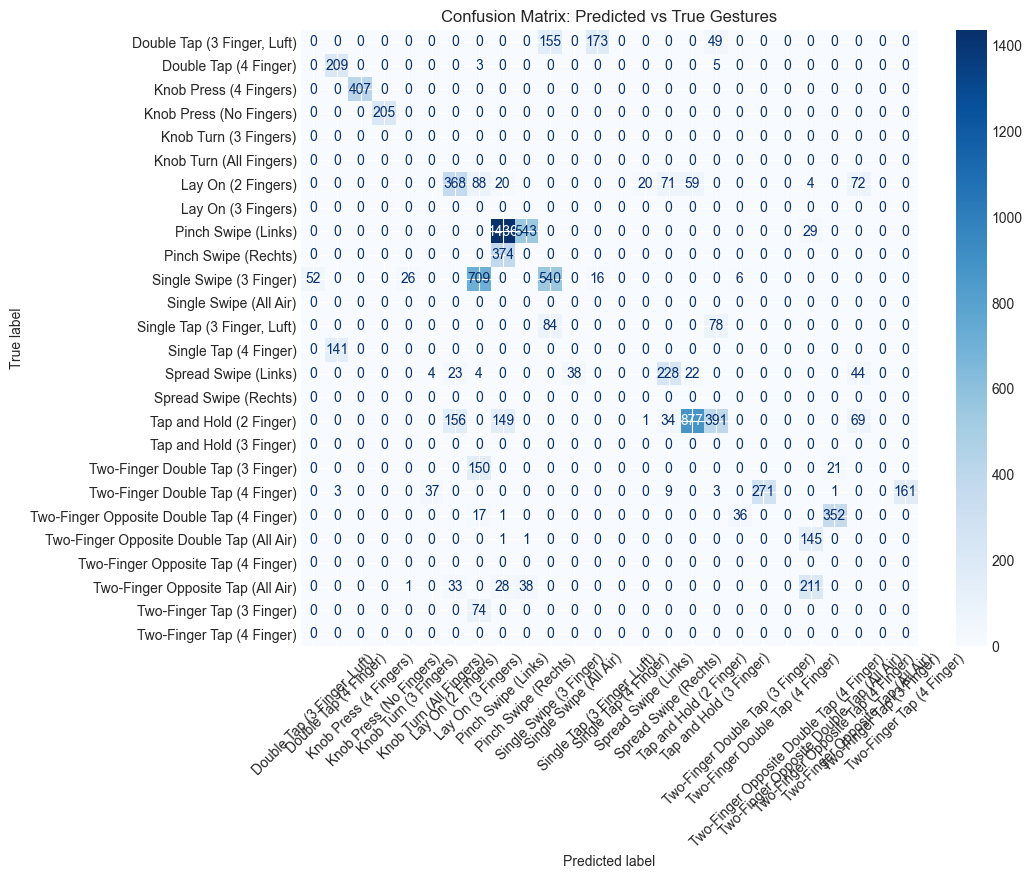

In [48]:
# --- Step 6: Final Evaluation ---
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Print full report
print("\nFinal Classification Report (on Test Sessions):")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# --- Step 7: Confusion Matrix ---
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix: Predicted vs True Gestures")
plt.show()

In [33]:
# 1. Get unique IDs in chronological order
unique_ids = df_ts_fresh['id'].unique()
split_point = int(len(unique_ids) * 0.8)

train_ids = unique_ids[:split_point]
test_ids = unique_ids[split_point:]

# 2. Filter the feature dataframe (df_features) using these IDs
# Since the index of df_features is (id, timestamp), we can filter by the first level
X_train = df_features.loc[df_features.index.get_level_values(0).isin(train_ids)]
X_test = df_features.loc[df_features.index.get_level_values(0).isin(test_ids)]

# 3. Do the same for your labels (y)
y_train = y.loc[X_train.index]
y_test = y.loc[X_test.index]

print(f"Training on {len(train_ids)} sessions, Testing on {len(test_ids)} sessions")

Training on 136 sessions, Testing on 34 sessions


In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder

# 1. Encode your string labels (e.g., 'Gesture A' -> 0)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Get the original IDs for grouping (to prevent data leakage)
groups = [idx[0] for idx in df_features.index]

# 3. Simple Train/Test Split (Group-based)
# For simplicity, let's just use a cross-validator
gkf = GroupKFold(n_splits=5)
clf = RandomForestClassifier(n_estimators=100)

for train_idx, test_idx in gkf.split(df_features, y_encoded, groups=groups):
    X_train, X_test = df_features.iloc[train_idx], df_features.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    
    clf.fit(X_train, y_train)
    print(f"Accuracy: {clf.score(X_test, y_test)}")
    break # Just showing the first fold

['002f4422-1f7b-4859-8f03-467e1f752000', '002f4422-1f7b-4859-8f03-467e1f752000', '002f4422-1f7b-4859-8f03-467e1f752000', '002f4422-1f7b-4859-8f03-467e1f752000', '002f4422-1f7b-4859-8f03-467e1f752000', '002f4422-1f7b-4859-8f03-467e1f752000', '002f4422-1f7b-4859-8f03-467e1f752000', '002f4422-1f7b-4859-8f03-467e1f752000', '002f4422-1f7b-4859-8f03-467e1f752000', '002f4422-1f7b-4859-8f03-467e1f752000']


In [34]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score

# Initialize the split (e.g., 5 folds)
tscv = TimeSeriesSplit(n_splits=5)

# Sort features by index to ensure strictly chronological order
df_features_sorted = df_features.sort_index()
y_sorted = y.loc[df_features_sorted.index]

for train_index, test_index in tscv.split(df_features_sorted):
    # Split the data
    cv_train_X, cv_test_X = df_features_sorted.iloc[train_index], df_features_sorted.iloc[test_index]
    cv_train_y, cv_test_y = y_sorted.iloc[train_index], y_sorted.iloc[test_index]
    
    # Train and evaluate
    model = RandomForestClassifier()
    model.fit(cv_train_X, cv_train_y)
    
    predictions = model.predict(cv_test_X)
    print(f"Fold Accuracy: {accuracy_score(cv_test_y, predictions)}")

Fold Accuracy: 0.031354515050167224
Fold Accuracy: 0.25
Fold Accuracy: 0.1149665551839465
Fold Accuracy: 0.30358138238573024
Fold Accuracy: 0.16374024526198439


In [ ]:
def create_sliding_windows_binary(session_df, window_size, step_size):
    session_df = session_df.sort_values('timestamp').reset_index(drop=True)
    # Add
    sensor_data = session_df[SENSOR_COLUMNS].values
    gesture_labels = session_df['gesture'].values
    
    n_samples = len(sensor_data)
    windows = []
    window_labels = []
    window_metadata = []
    
    for start_idx in range(0, n_samples - window_size + 1, step_size):
        end_idx = start_idx + window_size
        
        window = sensor_data[start_idx:end_idx]
        window_label_segment = gesture_labels[start_idx:end_idx]
        
        # Determine window label based on majority class (if it is conflicting, print a warning - conflicting is when there are multiple classes with a percentage greater than 30%), Ignoring No Gesture Label
        unique, counts = np.unique(window_label_segment, return_counts=True)
        # Remove 'No Gesture' from consideration
        if 'No Gesture' in unique:
            no_gesture_index = np.where(unique == 'No Gesture')[0][0]
            unique = np.delete(unique, no_gesture_index)
            counts = np.delete(counts, no_gesture_index)
        label_counts = dict(zip(unique, counts))
        total_counts = sum(counts)
        label_percentages = {label: (count / total_counts) * 100 for label, count in label_counts.items()}
        sorted_labels = sorted(label_percentages.items(), key=lambda x: x[1], reverse=True)
        if len(sorted_labels) > 1 and sorted_labels[1][1] > 30:
            print(f"  WARNING: Conflicting labels in window [{start_idx}:{end_idx}] - {label_percentages}")
        # Take first label if exists, else 'No Gesture'
        window_label = sorted_labels[0][0] if sorted_labels else 'No Gesture'
        
        
        windows.append(window)
        window_labels.append(window_label)
        window_metadata.append({
            'session_task_id': session_df['session_task_id'].iloc[0],
            'participant_id': session_df['participant_id'].iloc[0],
            'start_idx': start_idx,
            'end_idx': end_idx,
        })
    
    return np.array(windows), np.array(window_labels), window_metadata


# Apply to all sessions
all_windows = []
all_labels = []
all_metadata = []

session_groups = df_binary.groupby('session_task_id')
total_sessions = len(session_groups)

print(f"Processing {total_sessions} sessions...")

for idx, (session_id, session_df) in enumerate(session_groups):
    if (idx + 1) % 10 == 0:
        print(f"  Processing session {idx + 1}/{total_sessions}...")
    
    if len(session_df) >= WINDOW_SIZE_SAMPLES:  # Only process if enough samples
        windows, labels, metadata = create_sliding_windows_binary(
            session_df,
            WINDOW_SIZE_SAMPLES,
            STEP_SIZE_SAMPLES
        )
        
        all_windows.extend(windows)
        all_labels.extend(labels)
        all_metadata.extend(metadata)

# Convert to numpy arrays
X_windows = np.array(all_windows)
y_binary = np.array(all_labels)

print(f"\nWindowing complete!")
print(f"  Total windows: {len(X_windows):,}")
print(f"  Window shape: {X_windows.shape}")
print(f"  (n_windows, window_size, n_features)")

# Check final class distribution
unique, counts = np.unique(y_binary, return_counts=True)
print(f"\nWINDOW LABEL DISTRIBUTION:")
for label, count in zip(unique, counts):
    percentage = (count / len(y_binary)) * 100
    print(f"  {label}: {count:,} windows ({percentage:.1f}%)")


In [ ]:
# Print the first window
print("\nExample window data (first window):")
print(X_windows[0])

In [ ]:
def extract_features(window, sampling_rate_hz=50.0):
    """
    window: np.ndarray of shape (T, num_sensors)
    sampling_rate_hz: sampling frequency of your controller
    """
    dt = 1.0 / sampling_rate_hz
    features = []

    # Indices: button=0, motor=1, touch_pos=[2,5,8,11,14], touch_press=[3,6,9,12,15]
    button_col = 0
    motor_col = 1
    touch_pressure_cols = [3, 6, 9, 12, 15]
    touch_position_cols = [2, 5, 8, 11, 14]

    # Helper for safe stats on empty arrays
    def safe_stat(fn, arr, default=0.0):
        return fn(arr) if arr.size > 0 else default

    # ---------------- BUTTON FEATURES ----------------
    button = window[:, button_col].astype(float)
    features.append(np.mean(button > 0.5))          # Button press ratio
    features.append(np.any(button > 0.5).astype(float))  # Any press

    # Optional: longest continuous press duration (in seconds)
    if button.size > 0:
        pressed = button > 0.5
        # lengths of consecutive True segments
        if pressed.any():
            # Diff-based run-length encoding
            changes = np.diff(pressed.astype(int))
            starts = np.where(changes == 1)[0] + 1
            ends   = np.where(changes == -1)[0] + 1
            if pressed[0]:
                starts = np.r_[0, starts]
            if pressed[-1]:
                ends = np.r_[ends, len(pressed)]
            run_lengths = (ends - starts) * dt
            longest_press = np.max(run_lengths)
        else:
            longest_press = 0.0
    else:
        longest_press = 0.0
    features.append(longest_press)

    # ---------------- MOTOR FEATURES ----------------
    motor = window[:, motor_col].astype(float)
    if motor.size > 1:
        vel = np.diff(motor) / dt
        acc = np.diff(vel) / dt
        jerk = np.diff(acc) / dt  # captures sharp changes in motion [web:15][web:17]
    else:
        vel = acc = jerk = np.array([], dtype=float)

    # Basic statistics
    features.extend([
        safe_stat(np.mean, motor),     # mean angle
        safe_stat(np.std, motor),      # angle variability
        safe_stat(np.ptp, motor),      # angle range
        safe_stat(np.max, motor),      # max angle
    ])

    # Kinematic features (magnitude of motion)
    for sig in (vel, acc, jerk):
        features.extend([
            safe_stat(lambda x: np.sum(np.abs(x)), sig),  # total magnitude
            safe_stat(lambda x: np.max(np.abs(x)), sig),  # max magnitude
        ])

    # Motion smoothness: ratio of jerk to velocity energy (higher = less smooth) [web:15][web:19]
    vel_energy = safe_stat(lambda x: np.sum(x**2), vel, default=1e-6)
    jerk_energy = safe_stat(lambda x: np.sum(x**2), jerk)
    smoothness = jerk_energy / vel_energy
    features.append(smoothness)

    # ---------------- TOUCH FEATURES ----------------
    touch_pressures = window[:, touch_pressure_cols].astype(float)
    touch_positions = window[:, touch_position_cols].astype(float)

    # Active touch mask
    active_mask = touch_pressures > 0.0
    active_count_per_t = np.sum(active_mask, axis=1)

    # Global activity features
    features.extend([
        np.max(active_count_per_t),           # max simultaneous touches
        np.mean(active_count_per_t),          # avg simultaneous touches
        np.any(active_mask).astype(float),    # any touch at all
        np.sum(touch_pressures),              # total pressure
        np.max(touch_pressures) if touch_pressures.size else 0.0,  # max pressure
    ])

    # Per-touch temporal features (fraction of time active)
    # Helpful to distinguish one-finger vs multi-finger gestures [web:20][web:31]
    if active_mask.size > 0:
        active_fraction_per_touch = np.mean(active_mask, axis=0)
        features.extend(list(active_fraction_per_touch))
    else:
        features.extend([0.0] * len(touch_pressure_cols))

    # Positions: movement along each touch and global path length
    if touch_positions.shape[0] > 1:
        pos_diff = np.diff(touch_positions, axis=0)
        # Per-touch path length and max jump
        path_length_per_touch = np.sum(np.abs(pos_diff), axis=0)
        max_jump_per_touch = np.max(np.abs(pos_diff), axis=0)

        features.extend(list(path_length_per_touch))   # fine-grained per touch
        features.extend(list(max_jump_per_touch))

        # Global measures across all touches
        features.append(np.sum(np.abs(pos_diff)))      # total touch movement
        features.append(np.max(np.abs(pos_diff)))      # max position jump

        # Approximate velocity/acc for positions (common in gesture work) [web:17][web:29]
        pos_vel = pos_diff / dt
        pos_acc = np.diff(pos_vel, axis=0) / dt if pos_vel.shape[0] > 1 else np.zeros_like(pos_vel)
        features.extend([
            np.sum(np.abs(pos_vel)),                   # total positional velocity
            np.max(np.abs(pos_vel)),                   # max positional velocity
            np.sum(np.abs(pos_acc)),                   # total positional acceleration
            np.max(np.abs(pos_acc)),                   # max positional acceleration
        ])
    else:
        # same number of zeros as above branches
        num_touches = len(touch_position_cols)
        features.extend([0.0] * num_touches)   # path_length_per_touch
        features.extend([0.0] * num_touches)   # max_jump_per_touch
        features.extend([0.0, 0.0])            # total movement, max jump
        features.extend([0.0, 0.0, 0.0, 0.0])  # pos_vel/pos_acc stats

    # ---------------- NORMALIZATION HINT ----------------
    # Strongly recommended in your pipeline (outside this function):
    # - Standardize each feature over the dataset
    # - Optionally, per-user normalization for motor angle / positions [web:22][web:30]

    return np.asarray(features, dtype=np.float32)


# Extract features for all windows
print("Extracting simple features from windows...")

import time
start_time = time.time()

X_features_simple = np.array([extract_features(window) for window in X_windows])

extraction_time = time.time() - start_time
time_per_window = (extraction_time / len(X_windows)) * 1000  # ms

print(f"\n Feature extraction complete!")
print(f"  Feature matrix shape: {X_features_simple.shape}")
print(f"  Features per window: {X_features_simple.shape[1]}")
print(f"  Total extraction time: {extraction_time:.2f}s")
print(f"  Time per window: {time_per_window:.4f}ms")

print(f"\n FEATURE BREAKDOWN:")
print(f"  TOTAL: {X_features_simple.shape[1]} features")


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Create metadata DataFrame
metadata_df = pd.DataFrame(all_metadata)

# grouping_col = 'participant_id'
grouping_col = 'session_task_id'

# 2. Get unique participant IDs (the unit of splitting)
# TODO Use participants once there are more recordings
unique_dataset = metadata_df[grouping_col].unique()
print(f"Total {grouping_col}: {len(unique_dataset)}")

# 3. Split by participant ID (not session or window!)
train_dataset, test_dataset = train_test_split(
    unique_dataset,
    test_size=0.3, # Defines the percentage of participants to be in the test set
    random_state=42
)

print(f"\n Split Participants:")
print(f"  Training participants: {len(train_dataset)}")
print(f"  Test participants: {len(test_dataset)}")

# 4. Get window indices based on the participant split
# A window is 'train' if its participant ID is in the train_dataset list
train_mask = metadata_df[grouping_col].isin(train_dataset)
test_mask = metadata_df[grouping_col].isin(test_dataset)

# 5. Split data
X_train = X_features_simple[train_mask]
X_test = X_features_simple[test_mask]
y_train = y_binary[train_mask]
y_test = y_binary[test_mask]

# --- VERIFICATION & OUTPUT (Your original excellent checks) ---

print(f"\n Windows split:")
print(f"  Training windows: {len(X_train):,} ({len(X_train)/len(X_features_simple)*100:.1f}%)")
print(f"  Test windows: {len(X_test):,} ({len(X_test)/len(X_features_simple)*100:.1f}%)")

print(f"\n TRAINING SET:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    print(f"  {label}: {count:,} ({count/len(y_train)*100:.1f}%)")

print(f"\n TEST SET:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for label, count in zip(unique_test, counts_test):
    print(f"  {label}: {count:,} ({count/len(y_test)*100:.1f}%)")

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale features (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features scaled using StandardScaler")
print(f"  Training mean: {X_train_scaled.mean():.4f}")
print(f"  Training std: {X_train_scaled.std():.4f}")


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
# Compute class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {cls: weight for cls, weight in zip(np.unique(y_train), class_weights)}

print("\nClass Weights:")
for cls, weight in class_weight_dict.items():
    print(f"  {cls}: {weight:.4f}")


In [ ]:
# Import classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# ============================================================
# 1. COST MODEL (ADJUST THESE!)
# ============================================================

COST_FN = 35.0   # Missing a true event is VERY bad
COST_FP = 20.0   # Extra multiclass inference is tolerable

THRESHOLDS = np.linspace(0.01, 0.99, 350)

# ============================================================
# 2. THRESHOLD OPTIMIZATION (MIN TOTAL COST)
# ============================================================

def get_best_threshold_for_min_cost(y_true, y_probs):
    best_cost = float("inf")
    best_thresh = 0.5
    best_cm = None

    for thresh in THRESHOLDS:
        y_pred = (y_probs >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        total_cost = COST_FN * fn + COST_FP * fp

        if total_cost < best_cost:
            best_cost = total_cost
            best_thresh = thresh
            best_cm = (tn, fp, fn, tp)

    return best_thresh, best_cost, best_cm


# ============================================================
# 3. RESULT PRINTING
# ============================================================

def print_binary_results(
    name,
    y_true,
    y_pred,
    best_params,
    best_threshold,
    inference_time_ms,
    total_cost
):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    recall = recall_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    print("-" * (len(name) + 45))
    print(f"Cost-Optimized Results for {name}")
    print(f"  Best Hyperparameters: {best_params}")
    print(f"  Optimal Threshold: {best_threshold:.4f}")

    print("\nConfusion Matrix:")
    print(f"  TN: {tn:,}")
    print(f"  FP: {fp:,}")
    print(f"  FN: {fn:,}")
    print(f"  TP: {tp:,}")

    print("\nMetrics:")
    print(f"  Recall: {recall:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  FPR: {fpr:.4f}")
    print(f"  F1: {f1:.4f}")

    print("\nCost:")
    print(f"  Total Cost: {total_cost:.2f}")
    print(f"  Cost / sample: {total_cost / len(y_true):.4f}")

    print("\nInference:")
    print(f"  Time per sample: {inference_time_ms:.4f} ms\n")


# ============================================================
# 4. CLASSIFIERS & GRIDS
# ============================================================

RANDOM_STATE_PARAMS = {'random_state': 42}
CLASS_WEIGHT_PARAMS = {'class_weight': 'balanced'}

classifiers = [
    {
        'name': 'Logistic Regression',
        'estimator': LogisticRegression(
            solver='saga',
            max_iter=2000,
            **RANDOM_STATE_PARAMS,
            **CLASS_WEIGHT_PARAMS
        ),
        'param_grid': {'C': [0.01, 0.1, 1.0, 10]},
    },
    {
        'name': 'Decision Tree',
        'estimator': DecisionTreeClassifier(
            **RANDOM_STATE_PARAMS,
            **CLASS_WEIGHT_PARAMS
        ),
        'param_grid': {'max_depth': [None, 5, 10, 15], 'min_samples_split': [2, 5, 10]},
    },
    {
        'name': 'Random Forest',
        'estimator': RandomForestClassifier(
            n_estimators=100,
            **RANDOM_STATE_PARAMS,
            **CLASS_WEIGHT_PARAMS
        ),
        'param_grid': {'max_depth': [None, 3, 5, 10, 15], 'n_estimators': [25, 50, 100, 150, 200], 'min_samples_split': [2, 4, 5, 8, 10], 'min_samples_leaf': [1, 2, 6, 8], 'criterion': ['gini', 'entropy']},
    },
    {
        'name': 'KNN',
        'estimator': KNeighborsClassifier(),
        'param_grid': {'n_neighbors': [5, 10, 20, 25], 'weights': ['uniform', 'distance']},
    },
    {
        'name': 'Gradient Boosting',
        'estimator': GradientBoostingClassifier(
            subsample=0.7,
            **RANDOM_STATE_PARAMS
        ),
        'param_grid': {'n_estimators': [25, 50, 75, 100, 150], 'max_depth': [None, 2, 3, 5, 8], 'learning_rate': [0.035, 0.05, 0.1]},
        'use_sample_weight': True
    },
    {
        'name': 'XGBoost',
        'estimator': XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            **RANDOM_STATE_PARAMS
        ),
        'param_grid': {
            'n_estimators': [50, 100, 150],
            'max_depth': [3, 5, 76],
            'learning_rate': [0.03, 0.05, 0.1],
            'scale_pos_weight': [scale_pos_weight]
        },
        'use_sample_weight': True
    }
]

# ============================================================
# 5. TRAINING + COST-BASED SELECTION
# ============================================================

print("\nStarting Cost-Optimized Training")
print(f"COST_FN={COST_FN}, COST_FP={COST_FP}")

best_overall = {
    "name": None,
    "estimator": None,
    "params": None,
    "threshold": None,
    "cost": float("inf"),
    "inference_time_ms": None
}


for model in classifiers:
    name = model['name']
    estimator = model['estimator']
    param_grid = model['param_grid']

    fit_params = {}
    if model.get('use_sample_weight'):
        fit_params['sample_weight'] = class_weights[y_train]

    print(f"\n--- Training {name} ---")

    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring='recall',  # coarse filter only
        cv=3,
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train_scaled, y_train, **fit_params)

    best_estimator = grid.best_estimator_
    best_params = grid.best_params_

    # Inference timing
    start = time.time()
    y_probs = best_estimator.predict_proba(X_test_scaled)[:, 1]
    inference_time_ms = (time.time() - start) / len(y_test) * 1000

    # Cost-optimized threshold
    best_thresh, best_cost, _ = get_best_threshold_for_min_cost(y_test, y_probs)
    y_pred = (y_probs >= best_thresh).astype(int)

    if best_cost < best_overall["cost"]:
        best_overall.update({
            "name": name,
            "estimator": best_estimator,
            "params": best_params,
            "threshold": best_thresh,
            "cost": best_cost,
            "inference_time_ms": inference_time_ms
        })

    print_binary_results(
        name=name,
        y_true=y_test,
        y_pred=y_pred,
        best_params=best_params,
        best_threshold=best_thresh,
        inference_time_ms=inference_time_ms,
        total_cost=best_cost
    )

print("\nCost-optimized evaluation complete.")

print("\n" + "=" * 60)
print("🏆 BEST GATEKEEPER MODEL (MIN TOTAL COST)")
print("=" * 60)

print(f"Model: {best_overall['name']}")
print(f"Best Hyperparameters: {best_overall['params']}")
print(f"Optimal Threshold: {best_overall['threshold']:.4f}")
print(f"Total Cost: {best_overall['cost']:.2f}")
print(f"Inference Time per Sample: {best_overall['inference_time_ms']:.4f} ms")

y_probs_best = best_overall["estimator"].predict_proba(X_test_scaled)[:, 1]
y_pred_best = (y_probs_best >= best_overall["threshold"]).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

print("\nConfusion Matrix (Best Model):")
print(f"  TN: {tn:,}")
print(f"  FP: {fp:,}")
print(f"  FN: {fn:,}")
print(f"  TP: {tp:,}")

# Print True Positive Rate and False Positive Rate
tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
f1 = (2 * precision * tpr) / (precision + tpr) if (precision + tpr) > 0 else 0.0
print(f"\nTrue Positive Rate (Recall): {tpr:.4f}")
print(f"Precision: {precision:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"F1 Score: {f1:.4f}\n")


In [ ]:
# Test the best model with the szenarien dataset, create the windows then create features and scale them and finally predict, then check results and compare with labelled gestures


In [ ]:
# Step 1: Create sliding windows
szenarien_df_binary = szenarien_df.copy()
szenarien_df_binary['timestamp'] = pd.to_datetime(szenarien_df_binary['timestamp'])
szenarien_df_binary = szenarien_df_binary.sort_values(['session_task_id', 'timestamp']).reset_index(drop=True)
# Handle missing values
for col in SENSOR_COLUMNS:
    if col in szenarien_df_binary.columns:
        szenarien_df_binary[col] = szenarien_df_binary.groupby('session_task_id')[col].fillna(method='ffill')
        szenarien_df_binary[col] = szenarien_df_binary.groupby('session_task_id')[col].fillna(method='bfill')
szenarien_df_binary[SENSOR_COLUMNS] = szenarien_df_binary[SENSOR_COLUMNS].fillna(0)
szenarien_windows = []
szenarien_window_metadata = []
session_groups_szenarien = szenarien_df_binary.groupby('session_task_id')
for session_id, session_df in session_groups_szenarien:
    if len(session_df) >= WINDOW_SIZE_SAMPLES:  # Only process if enough samples
        windows, _, metadata = create_sliding_windows_binary(
            session_df,
            WINDOW_SIZE_SAMPLES,
            STEP_SIZE_SAMPLES
        )
        szenarien_windows.extend(windows)
        szenarien_window_metadata.extend(metadata)
szenarien_X_windows = np.array(szenarien_windows)
print(f"Szenarien windows created: {szenarien_X_windows.shape}")

In [ ]:
# Step 2: Extract features
szenarien_X_features = np.array([extract_simple_features(window) for window in szenarien_X_windows])
print(f"Szenarien features extracted: {szenarien_X_features.shape}")

In [ ]:
# Step 2.1: Check for NaNs in the features
if np.isnan(szenarien_X_features).any():
    print("Warning: NaN values found in Szenarien features. Filling with zeros.")
    szenarien_X_features = np.nan_to_num(szenarien_X_features)

In [ ]:
# Step 3: Scale features
szenarien_X_scaled = scaler.transform(szenarien_X_features)
print(f"Szenarien features scaled: {szenarien_X_scaled.shape}")

In [ ]:
# Step 4: Predict with best model
szenarien_y_probs = best_overall["estimator"].predict_proba(szenarien_X_scaled)[:, 1]
szenarien_y_pred = (szenarien_y_probs >= best_overall["threshold"]).astype(int)
print(f"Szenarien predictions made: {szenarien_y_pred.shape}")

In [ ]:
# Step 4: Evaluate predictions
print("\nEvaluating Szenarien Predictions:")
# Create true labels based on gesture presence in metadata
szenarien_y_true = np.array([
    1 if meta.get('gesture_percentage', 0) > GESTURE_PERCENTAGE_THRESHOLD else 0
    for meta in szenarien_window_metadata
])
tn, fp, fn, tp = confusion_matrix(szenarien_y_true, szenarien_y_pred).ravel()
print("\nConfusion Matrix (Szenarien):")
print(f"  TN: {tn:,}")
print(f"  FP: {fp:,}")
print(f"  FN: {fn:,}")
print(f"  TP: {tp:,}")
# Print True Positive Rate and False Positive Rate
tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
f1 = (2 * precision * tpr) / (precision + tpr) if (precision + tpr) > 0 else 0.0
print(f"\nTrue Positive Rate (Recall): {tpr:.4f}")
print(f"Precision: {precision:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"F1 Score: {f1:.4f}\n")